In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')

### Column Types

---

1. ID Column: student_id → usually just for reference, not for analysis
2. Numeric Columns: age, study_hours, attendance_percentage, math_score, science_score, english_score, overall_score, travel_time_min
3. Categorical Columns: gender, school_type, parent_education, internet_access, travel_time, extra_activities, study_method, final_grade

In [3]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,travel_time_min
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000
mean,7500.500000,16.476400,4.25936,74.991760,63.774553,63.751227,63.709227,64.015500,37.57750
std,4330.271354,1.704475,2.17244,14.401139,20.919958,21.027675,20.860201,18.977811,25.27717
min,1.000000,14.000000,0.50000,50.000000,0.000000,0.000000,0.000000,14.500000,7.50000
25%,3750.750000,15.000000,2.40000,62.600000,48.200000,48.100000,48.300000,49.000000,22.50000
50%,7500.500000,16.000000,4.30000,75.000000,64.100000,64.000000,64.200000,64.300000,45.00000
75%,11250.250000,18.000000,6.10000,87.400000,80.100000,80.100000,80.000000,79.100000,45.00000
max,15000.000000,19.000000,8.00000,100.000000,100.000000,100.000000,100.000000,100.000000,75.00000


In [4]:
pd.crosstab(df['gender'],df['final_grade'])

final_grade,a,b,c,d,e,f
gender,,,,,,
female,253,542,1273,1236,1084,591
male,217,552,1231,1249,1137,593
other,251,544,1193,1285,1157,612


<Axes: xlabel='study_method'>

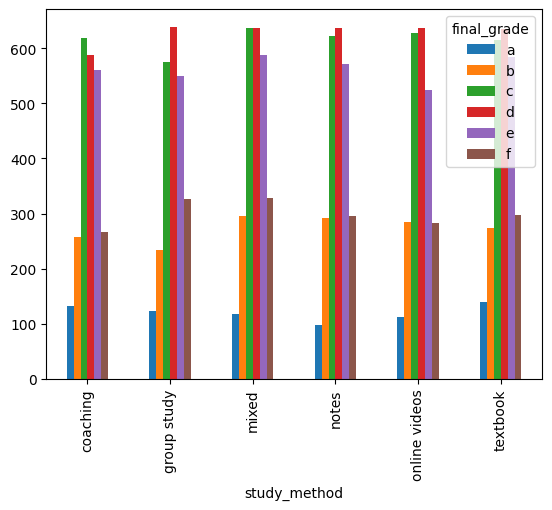

In [5]:
pd.crosstab(df['study_method'],df['final_grade']).plot(kind='bar')

<Axes: xlabel='attendance_percentage', ylabel='overall_score'>

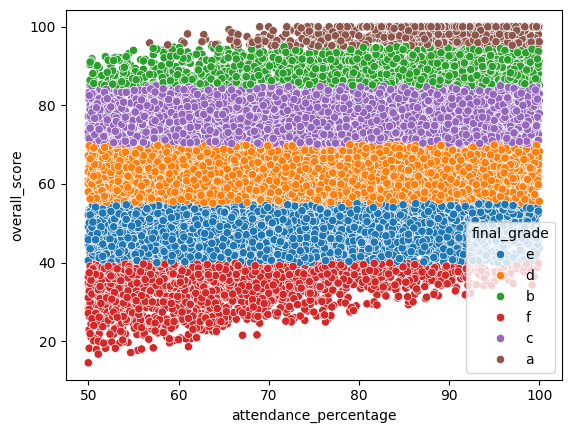

In [6]:
sns.scatterplot(x='attendance_percentage',y="overall_score",hue='final_grade',data=df)

In [7]:
df['study_hours'].describe()

count    15000.00000
mean         4.25936
std          2.17244
min          0.50000
25%          2.40000
50%          4.30000
75%          6.10000
max          8.00000
Name: study_hours, dtype: float64

In [8]:
df['attendance_percentage'].corr(df['overall_score'])

np.float64(0.28847322776538414)

In [9]:
pd.crosstab(df['travel_time'],df['final_grade'])

final_grade,a,b,c,d,e,f
travel_time,,,,,,
15-30 min,182,417,958,942,868,456
30-60 min,178,391,943,950,882,469
<15 min,176,379,925,933,805,430
>60 min,185,451,871,945,823,441


<Axes: xlabel='travel_time', ylabel='overall_score'>

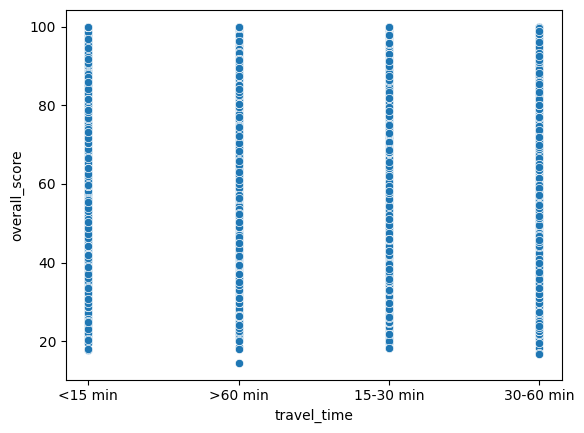

In [10]:
sns.scatterplot(x='travel_time',y='overall_score',data=df)

Do study_hours and attendance_percentage have a linear relationship with overall_score?

Text(0.5, 1.0, 'Study Hours vs Overall Score')

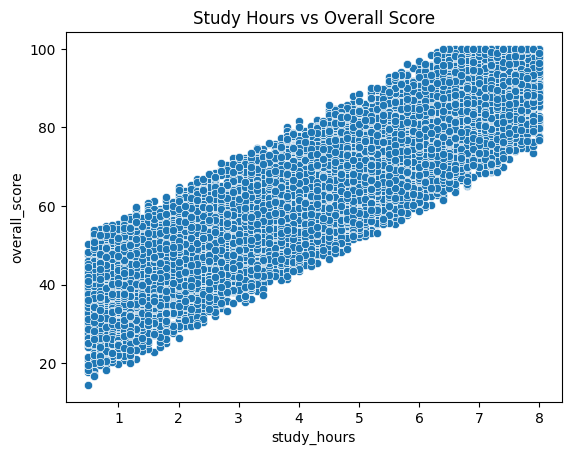

In [11]:
sns.scatterplot(x='study_hours', y='overall_score', data=df)
plt.title("Study Hours vs Overall Score")

Text(0.5, 1.0, 'Attendance Percentage vs Overall Score')

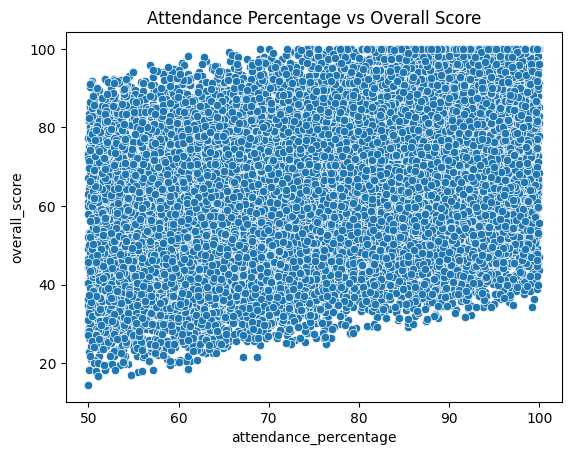

In [12]:
sns.scatterplot(x='attendance_percentage', y='overall_score', data=df)
plt.title("Attendance Percentage vs Overall Score")

Which parent_education category has the highest average overall score?

In [13]:
df['parent_education'][df['overall_score'] == df['overall_score'].max()].value_counts()

parent_education
diploma          60
phd              57
post graduate    53
high school      50
no formal        50
graduate         37
Name: count, dtype: int64

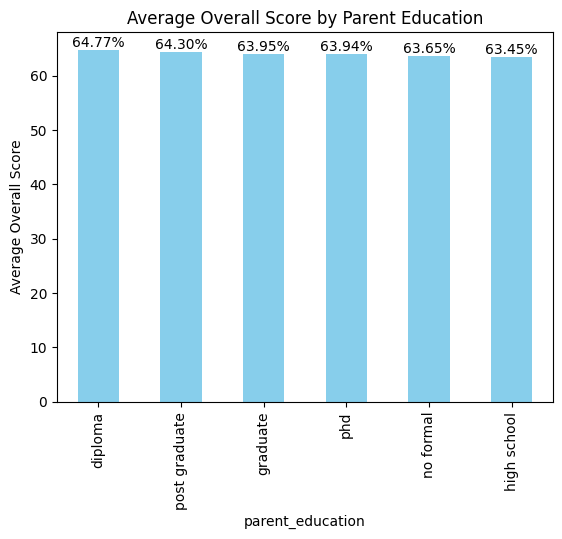

In [14]:
mean_scores = df.groupby('parent_education')['overall_score'].mean().sort_values(ascending=False)

bars = mean_scores.plot(kind='bar', color='skyblue')

for i, value in enumerate(mean_scores):
    bars.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.ylabel('Average Overall Score')
plt.title('Average Overall Score by Parent Education')
plt.show()

What is the average study_hours for each final_grade

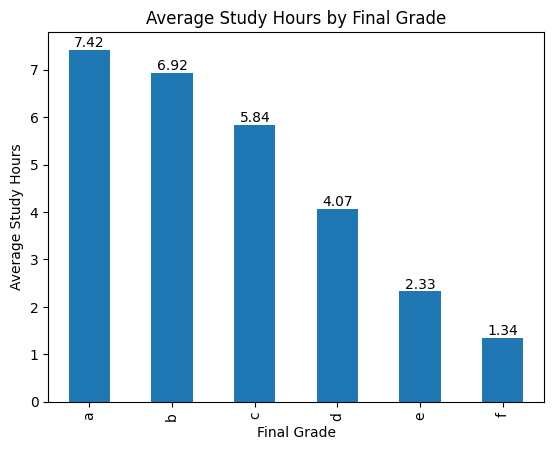

In [15]:
avg_hour = df.groupby('final_grade')['study_hours'].mean()

bars = avg_hour.plot(kind='bar')

for i,v in enumerate(avg_hour):
    bars.text(i,v,f'{v:.2f}',ha='center',va='bottom')

plt.ylabel('Average Study Hours')
plt.xlabel('Final Grade')
plt.title('Average Study Hours by Final Grade')
plt.show()

Does school_type (public/private) influence math_score or science_score on average?

In [16]:
df.groupby('school_type')[['math_score', 'science_score']].mean()

,math_score,science_score
school_type,,
private,63.789100,63.769105
public,63.759665,63.732929


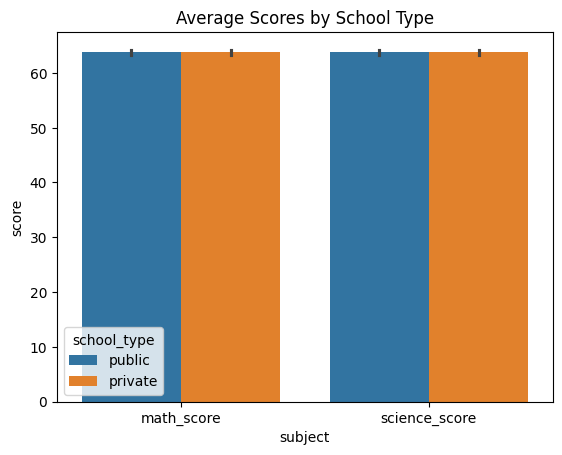

In [17]:
df_melted = df.melt(id_vars='school_type', value_vars=['math_score','science_score'],
                    var_name='subject', value_name='score')

sns.barplot(x='subject', y='score', hue='school_type', data=df_melted)
plt.title("Average Scores by School Type")
plt.show()

Are students involved in extra_activities performing better or worse than those who are not?

In [18]:
df.groupby('extra_activities')['overall_score'].mean()

extra_activities
no     63.969078
yes    64.061996
Name: overall_score, dtype: float64

In [19]:
pd.crosstab(df['gender'],df['study_hours'])

study_hours,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,...,7.1,7.2,7.3,7.4,7.5,7.6,7.7,7.8,7.9,8.0
gender,,,,,,,,,,,,,,,,,,,,,
female,35,64,70,62,55,62,77,77,75,72,...,60,66,57,68,66,86,79,68,56,38
male,29,63,72,56,61,77,80,61,66,76,...,72,63,79,83,64,66,67,59,70,19
other,36,63,77,60,62,69,83,67,79,70,...,68,69,71,60,72,62,66,66,74,40


<Axes: xlabel='study_hours', ylabel='final_grade'>

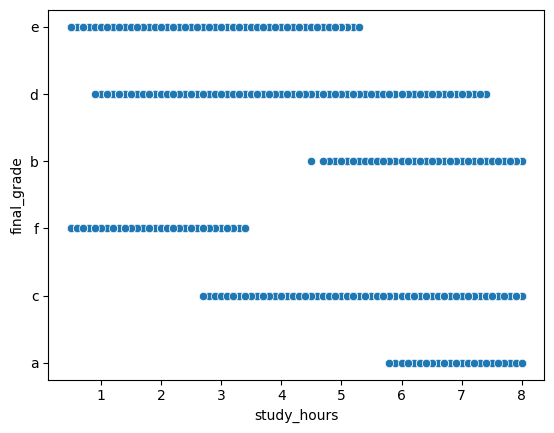

In [20]:
sns.scatterplot(x='study_hours', y='final_grade', data=df)